## Задание бустинги

Реализуйте один из классических алгоритмов бустинга AdaBoost. В коде должны использоваться решающие деревья в качестве базовых классификаторов. После реализации ответьте на вопросы и проведите эксперименты.
Напишите на Python класс (или набор функций), который реализует AdaBoost для классификации

Требования к реализации:

Базовый оценщик — DecisionTreeClassifier(max_depth=1).

Алгоритм должен: 

* Поддерживать параметр n_estimators (количество итераций бустинга).

* На каждой итерации вычислять веса объектов, ошибку модели и коэффициент доверия к текущему дереву.

* Возвращать предсказания как взвешенную сумму.

Допускается использование numpy и sklearn.tree.DecisionTreeClassifier, но запрещено использовать готовый sklearn.ensemble.AdaBoostClassifier (вы пишете их упрощённый аналог сами).

В своём ответе объясните (письменно, 1–2 абзаца):
1. Как бустинг отличается от Random Forest по принципу построения деревьев (параллельно vs последовательно) и по способу агрегации?
2. Почему в бустинге деревья обычно берут очень маленькими (max_depth=1..5), а в Random Forest — глубокими?
3. Как бустинг влияет на смещение (bias) и разброс (variance) модели по сравнению с RF?

Проведите мини-исследование на любом датасете (например, make_classification, breast_cancer или titanic). 
Для каждого вопроса проведите эксперимент: меняйте параметр, стройте график качества (например, ROC-AUC) от значения параметра.

Вопросы для исследования:
1. Сколько деревьев использовать (n_estimasets)?

2. Есть ли эффект переобучения при увеличении числа деревьев? Если да, то почему и как с ним бороться?

3. Что такое «ранняя остановка» (early stopping) и зачем она нужна в бустинге?

4. Как глубина деревьев влияет на результат (max_depth)?

5. Чем рискуют слишком глубокие деревья в бустинге?

6. Какая глубина даёт наилучший результат на выбранном Вами датасете?

7. Как связаны learning_rate и n_estimators?

8. Постройте график зависимости ошибки от learning_rate при фиксированном количестве деревьев.

In [185]:
import typing

import numpy
import sklearn.base
import sklearn.tree


class AdaBoostClassifier(sklearn.base.ClassifierMixin):
    def __init__(
        self,
        n_estimators: int = 50,
        learning_rate: float = 1.0,
        max_depth: int = 1,
        early_stopping_tol: float = 0.0,
        random_state: typing.Optional[int] = 42,
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.early_stopping_tol = early_stopping_tol
        self.random_state = random_state

    def fit(self, X: numpy.ndarray, y: numpy.ndarray):
        self.classes_, y = numpy.unique(y, return_inverse=True)

        rng = numpy.random.default_rng(self.random_state)
        weights = numpy.full(X.shape[0], 1.0 / X.shape[0])
        self.estimators_, self.estimator_weights_ = [], []
        for _ in range(self.n_estimators):
            model = sklearn.tree.DecisionTreeClassifier(
                max_depth=self.max_depth,
                random_state=int(rng.integers(0, numpy.iinfo(numpy.int32).max))
            )
            model.fit(X, y, sample_weight=weights)

            incorrect = model.predict(X) != y
            err = numpy.mean(numpy.average(incorrect, weights=weights, axis=0))
            if err <= self.early_stopping_tol:
                # Good enough classification
                self.estimators_.append(model)
                self.estimator_weights_.append(1.0)
                break

            alpha = numpy.log((1.0 - err) / err) + numpy.log(len(self.classes_) - 1.0)
            alpha *= self.learning_rate
            weights *= numpy.exp(alpha * incorrect)

            self.estimators_.append(model)
            self.estimator_weights_.append(alpha)
        return self

    def decision_function(self, X: numpy.ndarray) -> numpy.ndarray:
        scores = numpy.zeros((X.shape[0], len(self.classes_)), dtype=numpy.float32)
        for weight, model in zip(self.estimator_weights_, self.estimators_):
            scores[numpy.arange(X.shape[0]), model.predict(X)] += weight
        return scores

    def predict(self, X: numpy.ndarray) -> numpy.ndarray:
        return self.classes_[numpy.argmax(self.decision_function(X), axis=1)]

    def predict_proba(self, X):
        scores = self.decision_function(X)
        scores -= scores.max(axis=1, keepdims=True)
        scores = numpy.exp(scores)
        return scores / scores.sum(axis=1, keepdims=True)

> 1. Как бустинг отличается от Random Forest по принципу построения деревьев (параллельно vs последовательно) и по способу агрегации?

Random Forest строит деревья параллельно на подвыборках объектов и/или признаков и формирует итоговое предсказание путём голосования/усреднения предсказаний всех базовых моделей. Бустинг, в свою очередь, строит модели последовательно так, чтобы каждое следующее дерево стремилось исправлять ошибки предыдущих. Итоговое предсказание бустинга, таким образом, - это взвешенная сумма предсказаний базовых моделей.

> 3. Как бустинг влияет на смещение (bias) и разброс (variance) модели по сравнению с RF?

Каждая итерация бустинга уменьшает смещение (bias), все лучше и лучше подстраиваясь под данные и приближая их. При этом большое количество базовых моделей приводит к увеличению разброса (variance) и переобучению.

Random Forest, напротив, имеет такое же смещение (bias), как и одно дерево, но меньший разброс (variance). Усреднение базовых моделей уменьшает переобучение каждой отдельной из них, в результате чего снижается общий разброс композиции.

> 2. Почему в бустинге деревья обычно берут очень маленькими (max_depth=1..5), а в Random Forest — глубокими?

Это непосредственно следует из bias/variance декомпозиции этих моделей. Глубокое дерево имеет низкое смещение и высокий разброс.
- Random Forest сохраняет это низкое смещение (т.е. хорошую фиксацию закономерностей в данных), и дополнительно снижает разброс за счёт усреднение. В результате получается модель, у которой невелики обе части разложения.
- Бустинг, напротив, увеличивает разброс (т.е. переобучение) по мере добваления деревьев. Таким образом, для бустинга целесообразно использовать простые модели с низким разбросом (чтобы и композиция имела низкий разброс), а высокое смещение каждого отдельного дерева будет скомпенсировано непосредственно процедурой бустинга.

In [186]:
import tqdm
import sklearn.metrics
import sklearn.datasets
import sklearn.model_selection
import matplotlib.pyplot as plt

def score(y_true: numpy.ndarray, X: numpy.ndarray, model: AdaBoostClassifier) -> float:
    return sklearn.metrics.roc_auc_score(y_true, model.predict_proba(X), multi_class='ovo')

X, y = sklearn.datasets.load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline = AdaBoostClassifier().fit(X_train, y_train)
print(score(y_test, X_test, baseline))

0.9661029425985812


In [190]:
def run_experiment(param_values: list, model_builder):
    train_scores, test_scores = [], []
    for param in tqdm.tqdm(param_values):
        model = model_builder(param).fit(X_train, y_train)
        train_scores.append(score(y_train, X_train, model))
        test_scores.append(score(y_test, X_test, model))
    plt.plot(param_values, train_scores, marker='o', label="Train")
    plt.plot(param_values, test_scores, marker='o', label="Test")
    plt.grid(True, alpha=0.3)
    plt.legend()

> 1. Сколько деревьев использовать (n_estimasets)?
> 2. Есть ли эффект переобучения при увеличении числа деревьев? Если да, то почему и как с ним бороться?

В бустинговых композициях целесообразно использовать умеренное количество деревьев, так как рост разброса по мере добавления базовых моделей неизбежно приводит к переобучению на реальных данных.

Тем не менее на "игрушечных" данных переобучение практически не проявляется: разница в качестве предсказаний на тренировочной и тестовой выборках начинает немного увеличиваться, начиная с примерно 50 деревьев, но явные эффекты переобучения не заметны. Однако такое поведение является скорее исключением в связи с чрезмерной простотой набора данных; в реальном исследовании потребовалось бы аккуратно подобрать количество и параметры деревьев, чтобы побороть переобучение.

100%|██████████| 49/49 [00:15<00:00,  3.08it/s]


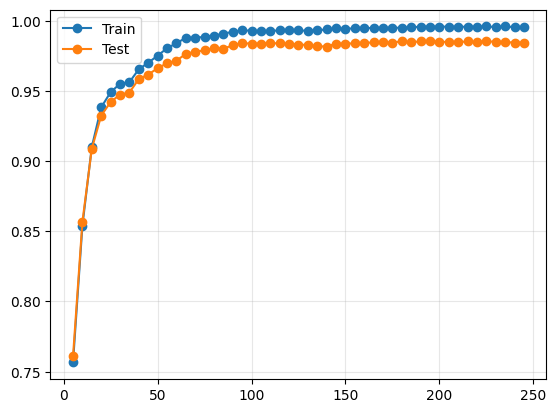

In [191]:
run_experiment(list(range(5, 250, 5)), lambda n_estimators: AdaBoostClassifier(n_estimators=n_estimators))

> 3. Что такое «ранняя остановка» (early stopping) и зачем она нужна в бустинге?

Ранняя остановка - это механизм завершения обучения при достижении некоторого порога ошибки. Обычно производится с использованием валидационной выборки: в модель перестают добавляться новые деревья по достижении установленного порога качества композиции на валидационной выборке. Это один из способов борьбы с переобучением: за счёт своевременной, ранней остановки модель не "перешагивает" оптимальное количество деревьев, а останавливается автоматически по достижении требуемого качества.

К сожалению, на "игрушечных" данных, доступных в scikit-learn, наблюдать эффект от ранней остановки в полной мере невозможно. В демонстрационных целях, будем производить остановку обучения по порогу ошибки на тренировочной выборке. Легко заметить, что при слишком высоком значении порога (т.е. при слишком ранней остановке), модель не успевает хорошо обучиться.

100%|██████████| 20/20 [00:02<00:00,  8.24it/s]


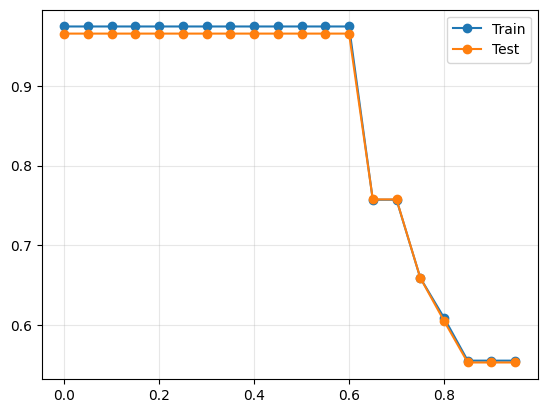

In [194]:
run_experiment(numpy.arange(0, 1, 0.05), lambda tol: AdaBoostClassifier(early_stopping_tol=tol))

> 4. Как глубина деревьев влияет на результат (max_depth)?
> 5. Чем рискуют слишком глубокие деревья в бустинге?
> 6. Какая глубина даёт наилучший результат на выбранном Вами датасете?

Глубокие деревья имеют высокий разброс, из-за чего композиция таких деревьев приводит к переобучению, что заметно даже на "игрушечных" данных: деревья глубины 9 и больше приводят к значимому разрыву между качеством на тренировочной и тестовой выборках, а начиная с глубины 14 результат на тестовых данных вовсе испытывает сильное падение. Наилучший результат на рассматриваемых данных достигают деревья с глубиной 6 - именно при этом значении гиперпараметра наблюдается наилучшее качество на тестовых данных и наименьшее различие качества на подвыборках.

100%|██████████| 19/19 [00:06<00:00,  2.89it/s]


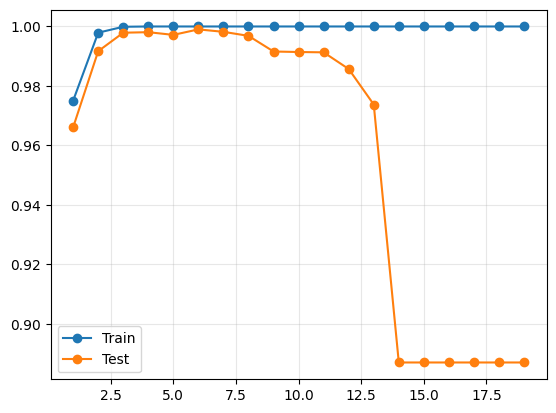

In [195]:
run_experiment(list(range(1, 20)), lambda depth: AdaBoostClassifier(max_depth=depth))

> 7. Как связаны learning_rate и n_estimators?
> 8. Постройте график зависимости ошибки от learning_rate при фиксированном количестве деревьев.

learning_rate позволяет управлять скоростью сходимости деревьев в композиции. Маленькие значения шага приводят к медленному снижению ошибки по мере добавления деревьев, но обычно сходятся к более стабильному и хорошему результату. Большие значения, в свою очередь, быстро приходят в окрестность минимума ошибки, но затрудняются найти сам минимум. Таким образом, маленький learning_rate требует большое количество n_estimators для сходимости, но достигает лучшего и более стабильного результаты. Большой learning_rate, в свою очередь, получает неплохой результат за сравнительно маленькое количество деревьев (n_estimators), но не достигает настоящего минимума ошибки.

100%|██████████| 20/20 [00:03<00:00,  6.19it/s]


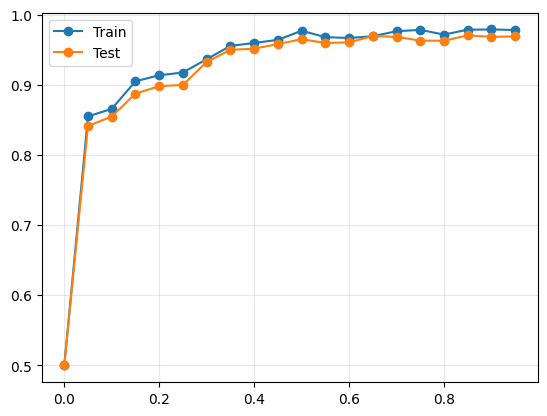

In [199]:
run_experiment(numpy.arange(0.0, 1.0, 0.05), lambda lr: AdaBoostClassifier(learning_rate=lr))

100%|██████████| 49/49 [00:29<00:00,  1.64it/s]


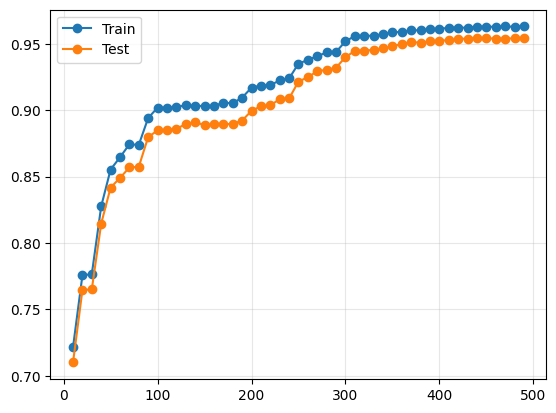

In [201]:
run_experiment(
    numpy.arange(10, 500, 10),
    lambda n_estimators: AdaBoostClassifier(n_estimators=n_estimators, learning_rate=0.05)
)